Code to generate Figure 6 subplots

In [3]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, pearsonr
from tqdm import trange
import matplotlib.ticker as ticker
import seaborn as sns
import networkx as nx
from matplotlib.ticker import LogFormatterMathtext

DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../flatten/processed-data/"
DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
MS_COLOR_LIGHT = "#EECC66" #color for static (in complex)
MS_COLOR_DARK  = "#997700" #color for dynamic (not in complex)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [4]:
# load the datasets with node centrality information and get nodes in both
#ms_nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")
#y2h_nodes = pd.read_csv(f"{DATA_PATH3}Y2H-s288c-step18.csv")
nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")

# --- Flip sign of cagiada-dG so downstream code uses the corrected values ---
nodes["cagiada-dG"] = -nodes["cagiada-dG"]

#y2h_nodes = y2h_nodes.merge(abundance_df, on="node", how="left")

#shared_nodes = set(ms_nodes["node"]) & set(y2h_nodes["node"])
#print (f"A total of {len(shared_nodes)} nodes are shared between the MS and Y2H networks")
#list(nodes.columns)

In [5]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2466


In [6]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10
ms_threshold = filtered_nodes['degree_centrality'].quantile(1 - cut)
ms_hubs     = filtered_nodes[filtered_nodes['degree_centrality'] >= ms_threshold]
ms_nothub   = filtered_nodes[filtered_nodes['degree_centrality'] <  ms_threshold]

#y2h_threshold = filtered_nodes['Y2H_degree_centrality'].quantile(1 - cut)
#y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] >= y2h_threshold]
#y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
#print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.01503; there are 252 hubs and 2214 non hubs


In [8]:
# Load chaperone data
# Parse the interacting_chaperones column if it's a string representation of a list
nodes['interacting_chaperones'] = nodes['interacting_chaperones'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Compute number of chaperone interactions
nodes['num_chaperone_interactions'] = nodes['interacting_chaperones'].apply(len)

# Compute total degree for each node from full MS interactome
f_ms_edges = pd.read_csv(f"{DATA_PATH1}The_Yeast_Interactome_edges.csv")
f_ms_edges = f_ms_edges.rename(columns={"source": "node1", "target": "node2"})

G = nx.from_pandas_edgelist(f_ms_edges, "node1", "node2", create_using=nx.Graph())
degree_dict = dict(G.degree())

degree_df = pd.DataFrame({
    "node": list(degree_dict.keys()),
    "total_degree": list(degree_dict.values())
})

# Merge degree and compute chaperone fraction
#Now every protein has: number of chaperone contacts, total degree, fraction of interactions involving chaperones
merged_df = nodes.merge(degree_df, left_on="node", right_on="node", how="inner")
merged_df = merged_df[merged_df['total_degree'] > 0] # avoid divide-by-zero
merged_df['chaperone_fraction'] = (100 * merged_df['num_chaperone_interactions'] / merged_df['total_degree'])

# Integrate classifications
class_df = filtered_nodes[['node', 'in_complex']].copy()

# Hub assignment for degree centrality
class_df['is_hub'] = class_df['node'].isin(ms_hubs['node'])

# Define hub type:
# static  = hub & in_complex == True
# dynamic = hub & in_complex == False
# nonhub  = everything else
def assign_hub_type(row):
    if row['is_hub']:
        return "static" if row['in_complex'] else "dynamic"
    else:
        return "nonhub"

class_df['hub_type'] = class_df.apply(assign_hub_type, axis=1)

# Merge classification into merged_df
final_df = merged_df.merge(
    class_df[['node', 'is_hub', 'hub_type']],
    on='node',
    how='left'
)

# Define simple chaperone boolean
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

#print(final_df.head())

Boxplot of chaperone association for hubs vs nonhubs.
Chaperone association % is chaperone fraction defined as (number of edges connecting a node to chaperone)/(total degree of the node)

In [9]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()
    
# Extract chaperone fraction for hubs vs non-hubs
hub_frac = final_df[final_df["is_hub"] == True]["chaperone_fraction"]\
                .replace([np.inf, -np.inf], np.nan).dropna()

nonhub_frac = final_df[final_df["is_hub"] == False]["chaperone_fraction"]\
                .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hubs",     hub_frac,    MS_COLOR),
    ("Non-hubs", nonhub_frac, MS_COLOR),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74859.07it/s]


Hubs: median=0.00, 95% CI=(0.00, 0.00), n=252)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:26<00:00, 38157.52it/s]

Non-hubs: median=0.00, 95% CI=(0.00, 0.00), n=2214)


In [7]:
# MWU test — Hubs vs Non-Hubs (chaperone fraction)
ms_u, ms_p = mannwhitneyu(hub_frac, nonhub_frac, alternative="two-sided")

print("=== Mann–Whitney U tests on Hubs vs Non-Hubs (chaperone fraction) ===")

print("\nHub + Chaperone vs Non-Hub + Chaperone")
print(f"n(hubs) = {len(hub_frac)}, n(nonhubs) = {len(nonhub_frac)}")
print(f"median(hubs) = {np.median(hub_frac):.2f}, median(nonhubs) = {np.median(nonhub_frac):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

#How many hubs have ≥1 chaperone contact?
print("Hubs median:", 
      (final_df[final_df["is_hub"] == True]["num_chaperone_interactions"] > 0).mean())
#How many nonhubs have ≥1 chaperone contact?
print("Nonhubs median:", 
      (final_df[final_df["is_hub"] == False]["num_chaperone_interactions"] > 0).mean())

=== Mann–Whitney U tests on Hubs vs Non-Hubs (chaperone fraction) ===

Hub + Chaperone vs Hub + NoChaperone
n(hubs) = 252, n(nonhubs) = 2214
median(hubs) = 0.00, median(nonhubs) = 0.00
U = 317619.50, p = 2.212e-08
Hubs median: 0.3253968253968254
Nonhubs median: 0.14588979223125564


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_41760/1825998234.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


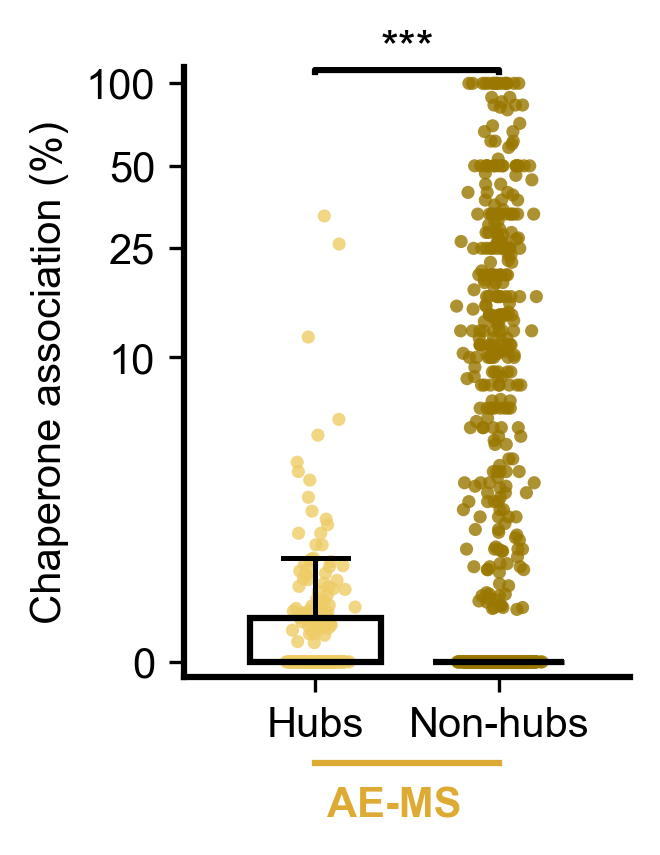

In [36]:
#####SHOULD ADD MINOR TICKS WHERE SYMLOG SCALE STARTS









def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 1.5     
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top + 0.015,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [hub_frac, nonhub_frac]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter ---
positions    = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots ---
bp = ax.boxplot(
    group_vals,
    labels=["Hubs", "Non-hubs"],
    positions=positions,
    widths=0.5,               
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)
        
ax.set_ylabel("Chaperone association (%)")
#ax.set_title("Degree Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# --- Axes styling ---
ax.set_yscale('symlog', linthresh=10)
ax.set_ylim(-0.1, max(hub_frac.max(), nonhub_frac.max()) + 0.15)
y_min = -0.5                 
y_max = 115
ax.set_ylim(y_min, y_max)


# Significance bracket slightly above the highest data point
#bracket_y = max(hub_frac.max(), nonhub_frac.max()) + 0.5   
bracket_y = 110

# Custom y-axis ticks
yticks = [0, 10, 25, 50, 100]
ax.set_yticks(yticks)
#ax.set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=10)
ax.set_yticklabels([f"{int(y)}" for y in yticks], fontsize=10)

# Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")

# Horizontal line
trans = ax.get_xaxis_transform()

ax.plot(
    [1.0, 1.7], [-0.14, -0.14],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.3, -0.18, "AE-MS",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6a-1.svg")
plt.show()

Boxplot of chaperone association % for Static vs Dynamic Hubs

In [9]:

# Extract static and dynamic hubs
static_df  = final_df[final_df["hub_type"] == "static"].copy()
dynamic_df = final_df[final_df["hub_type"] == "dynamic"].copy()

# Clean values
static_frac = static_df["chaperone_fraction"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_frac = dynamic_df["chaperone_fraction"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hubs",     static_frac,    MS_COLOR),
    ("Non-hubs", dynamic_frac, MS_COLOR),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 79451.81it/s]


Hubs: median=0.00, 95% CI=(0.00, 0.00), n=134)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 78745.84it/s]

Non-hubs: median=0.00, 95% CI=(0.00, 1.11), n=118)


In [10]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(static_frac, dynamic_frac, alternative="two-sided")

print("=== Mann–Whitney U tests on Static and Dynamic hubs (chaperone fraction) ===")

print("\nStatic hubs + Chaperone vs Dynamic Hubs + Chaperone")
print(f"n(static)  = {len(static_frac)}, n(dynamic) = {len(dynamic_frac)}")
print(f"median(static) = {np.median(static_frac):.2f}, median(dynamic) = {np.median(dynamic_frac):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

# Mean boolean (≥1 chaperone contact)
print("Static hubs median:", 
      (final_df[final_df["hub_type"] == "static"]["num_chaperone_interactions"] > 0).mean())

print("Dynamic hubs median:", 
      (final_df[final_df["hub_type"] == "dynamic"]["num_chaperone_interactions"] > 0).mean())

=== Mann–Whitney U tests on Hubs vs Non-Hubs (chaperone fraction) ===

Hub + Chaperone vs Hub + NoChaperone
n(static)  = 134, n(dynamic) = 118
median(static) = 0.00, median(dynamic) = 0.00
U = 5852.00, p = 1.934e-05
Static hubs median: 0.19402985074626866
Dynamic hubs median: 0.4745762711864407


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_41760/3245370647.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


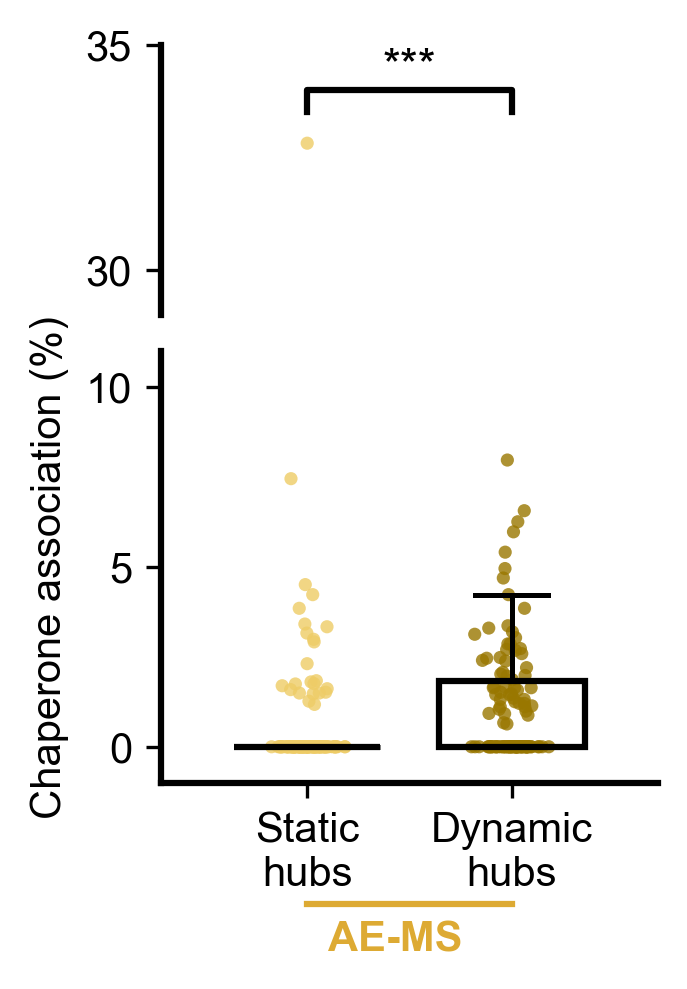

In [23]:
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 0.5 
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top + 0.015,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig = plt.figure(figsize=(2.3, 3))

# upper axis (outliers 30–40)
ax1 = fig.add_axes([0.18, 0.67, 0.72, 0.30])  

# lower axis (0–15)
ax2 = fig.add_axes([0.18, 0.15, 0.72, 0.48])

group_vals   = [static_frac, dynamic_frac]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# Scatter points
positions    = [1, 1.7]

# LOWER AXIS 
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax2.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )
bp = ax2.boxplot(
    group_vals,
    labels=["Static\nhubs", "Dynamic\nhubs"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)
for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)
    
for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)
        
ax2.set_ylim(-1, 11)
ax2.set_ylabel("Chaperone association (%)")

for spine in ["right", "top"]:
    ax2.spines[spine].set_visible(False)
ax2.spines["left"].set_linewidth(1.5)
ax2.spines["bottom"].set_linewidth(1.5)

# y-ticks on lower axis
ax2.set_yticks([0, 5, 10])
ax2.set_yticklabels(["0", "5", "10"], fontsize=10)

# UPPER AXIS
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    # only plot points > 30
    vals_upper = vals[vals >= 30]
    if len(vals_upper) > 0:
        ax1.scatter(
            np.full(len(vals_upper), pos),
            vals_upper,
            s=10,
            alpha=0.8,
            color=color,
            edgecolor="none",
            zorder=2,
        )

ax1.set_ylim(29, 35)
ax1.set_yticks([30, 35])
ax1.set_yticklabels(["30", "35"], fontsize=10)

# no x ticks here
ax1.set_xticks([])

for spine in ["right", "top"]:
    ax1.spines[spine].set_visible(False)
ax1.spines["left"].set_linewidth(1.5)
ax1.spines["bottom"].set_visible(False)

# Make sure both axes share the same x-limits
xlims = ax2.get_xlim()
ax1.set_xlim(xlims)

# Significance bracket on upper axis
bracket_y = 33.5
add_bracket_with_text(ax1, positions[0], positions[1], bracket_y, "***")

# Broken axis indicators 
d = 0.018
fig_w, fig_h = fig.get_size_inches()

ax1.plot([0.18 - d, 0.18 + d],
         [0.63 - d, 0.63 + d],
         transform=fig.transFigure, color="black", lw=1.2)

ax1.plot([0.9 - d, 0.9 + d],
         [0.63 - d, 0.63 + d],
         transform=fig.transFigure, color="black", lw=1.2)

# Horizontal line
trans = ax2.get_xaxis_transform()

ax2.plot(
    [1.0, 1.7], [-0.28, -0.28],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax2.text(
    1.3, -0.32, "AE-MS",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
#plt.tight_layout()
plt.savefig(f"{OUT_PATH}6a-2.svg")
plt.show()

Boxplot of stability (Ghosh–Dill ΔG) of chaperone associated hubs and chaperone independent hubs

In [37]:
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY 
hub_df = final_df[final_df["is_hub"] == True].copy()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 81377.11it/s]


Hub + Chaperone: median=-7.15, 95% CI=(-8.14, -6.82), n=82)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 75109.49it/s]

Hub + No Chaperone: median=-8.45, 95% CI=(-9.03, -8.09), n=170)


In [38]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on Ghosh-Dill-dG ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Ghosh-Dill-dG ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 82, n(nochap) = 170
median(chap) = -7.15, median(nochap) = -8.45
U = 8268.00, p = 0.01669


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_41760/2686136864.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


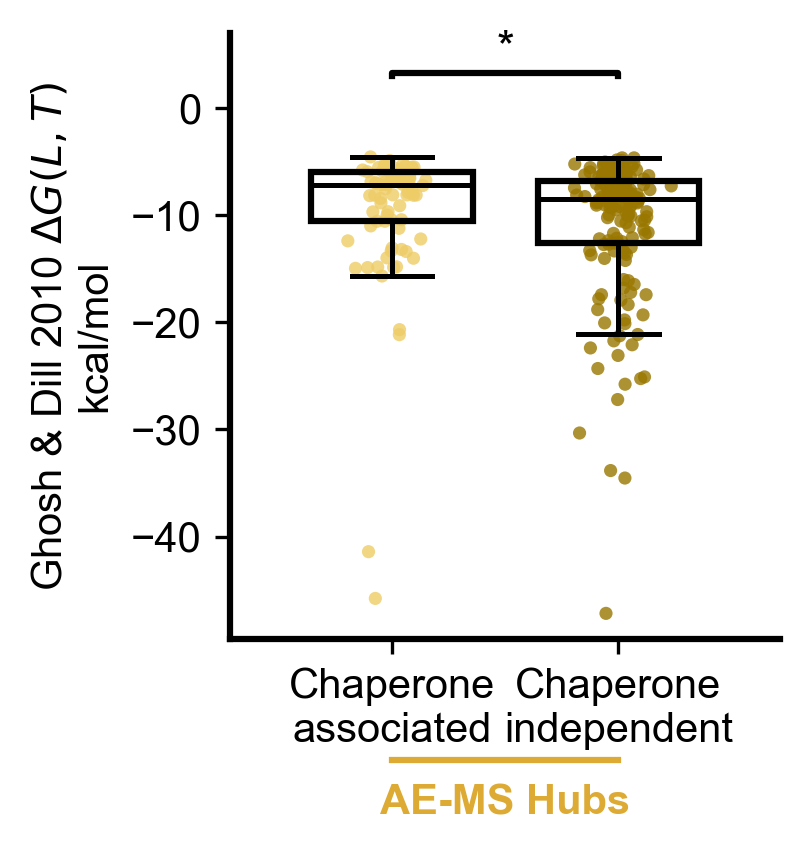

In [39]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\nassociated", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# Axes styling
ax.set_ylabel(r"Ghosh & Dill 2010 $ΔG(L,T)$" + "\nkcal/mol")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(hub_chap.min(), hub_nochap.min())
#y_max = max(hub_chap.max(), hub_nochap.max())
y_max = 0

# Significance bracket slightly above the highest data point
bracket_y = 3

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(y_min * 1.05, bracket_y + 4)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "*")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.20, -0.20],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.35, -0.24, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6b-1.svg")
plt.show()

Boxplot of stability (Cagiada ΔG) of chaperone associated hubs and chaperone independent hubs

In [40]:
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (degree-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 81747.21it/s]


Hub + Chaperone: median=-9.99, 95% CI=(-11.36, -8.06), n=82)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74896.50it/s]

Hub + No Chaperone: median=-12.86, 95% CI=(-13.79, -10.93), n=170)


In [41]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on cagiada-dG ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on cagiada-dG ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 82, n(nochap) = 170
median(chap) = -9.99, median(nochap) = -12.86
U = 7532.00, p = 0.3003


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_41760/2232352001.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


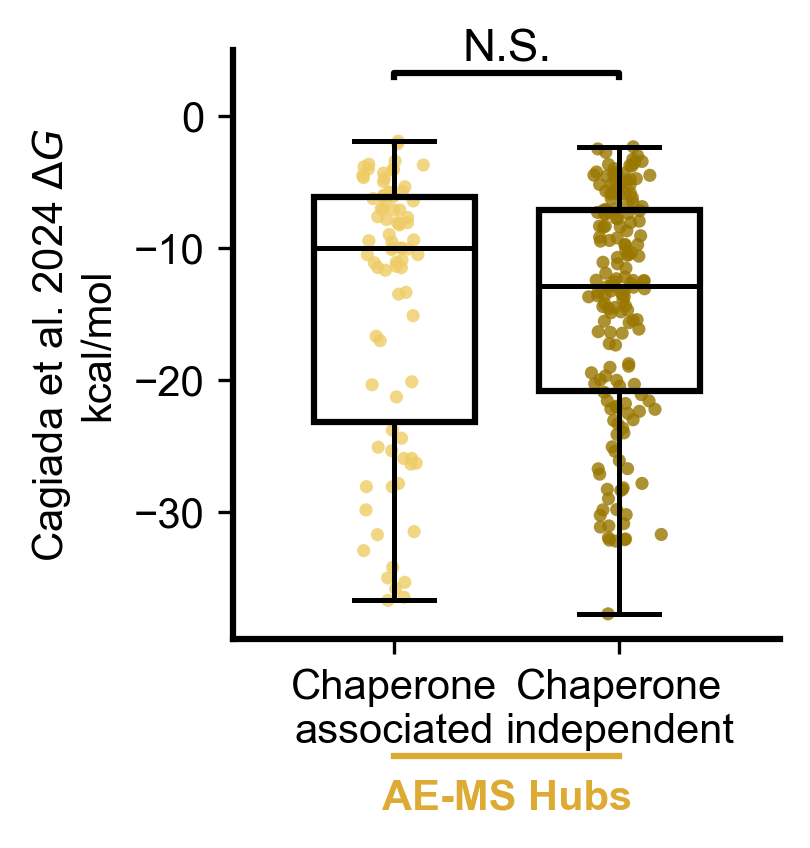

In [42]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\nassociated", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel(r"Cagiada et al. 2024 $ΔG$" + "\nkcal/mol")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(hub_chap.min(), hub_nochap.min())
y_max = 5

# Significance bracket slightly above the highest data point
bracket_y = 3

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(y_min * 1.05, y_max) 

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.20, -0.20],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.35, -0.24, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6b-2.svg")
plt.show()

Boxplot of stability (Rosetta Total Score) of chaperone associated hubs and chaperone independent hubs

In [43]:
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY 
hub_df = final_df[final_df["is_hub"] == True].copy()

rosetta_hub_chap     = hub_df[hub_df["has_chaperone"] == True]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
rosetta_hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups
groups = [
    ("Hub + Chaperone", rosetta_hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", rosetta_hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 80140.42it/s]


Hub + Chaperone: median=-537.69, 95% CI=(-669.16, -451.99), n=82)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74205.09it/s]

Hub + No Chaperone: median=-746.83, 95% CI=(-816.20, -654.67), n=170)


In [44]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(rosetta_hub_chap, rosetta_hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on Rosetta_best_total_score ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(rosetta_hub_chap)}, n(nochap) = {len(rosetta_hub_nochap)}")
print(f"median(chap) = {np.median(rosetta_hub_chap):.2f}, median(nochap) = {np.median(rosetta_hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Rosetta_best_total_score ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 82, n(nochap) = 170
median(chap) = -537.69, median(nochap) = -746.83
U = 8112.00, p = 0.03524


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_41760/2949281986.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


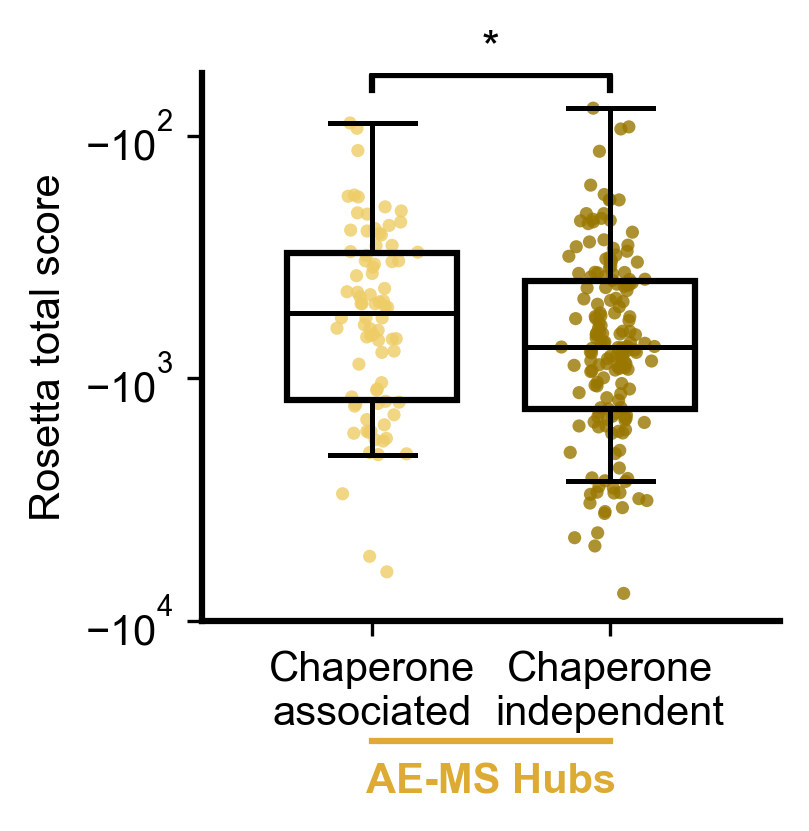

In [45]:
####### MINOR TICKS ON Y AXIS



# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y / 1.15
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top / 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [rosetta_hub_chap, rosetta_hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\nassociated", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Rosetta total score")

# === SYMLOG SCALE ===
ax.set_yscale('symlog', linthresh=10)

# Compute y-min and y-max FIRST
y_min = min(rosetta_hub_chap.min(), rosetta_hub_nochap.min())
#y_max = max(rosetta_hub_chap.max(), rosetta_hub_nochap.max())
y_max = -50

# Expand limits slightly
ax.set_ylim(y_min * 1.1, y_max * 1.1)

tick_locs = [-1e4, -1e3, -1e2]
ax.set_yticks(tick_locs)

ax.yaxis.set_major_formatter(LogFormatterMathtext())

# Minor ticks only on y-axis
ax.minorticks_on()
ax.xaxis.set_minor_locator(ticker.NullLocator())

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Place significance bracket at a fixed, nice height just above 0
bracket_y = -65  # you can adjust: -1, -3, -5 depending on taste
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "*")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.22, -0.22],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.35, -0.26, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6b-3.svg")
plt.show()

Boxplot of Meltome melting point of chaperone associated hubs and chaperone independent hubs

In [46]:
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (degree-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Ghosh–Dill values
hub_df["meltome-melting-point"] = hub_df[hub_df['meltome-fit-R2'] > 0.9]["meltome-melting-point"].replace([np.inf, -np.inf], np.nan).dropna()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 77158.64it/s]


Hub + Chaperone: median=42.96, 95% CI=(42.37, 44.72), n=69)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 79579.69it/s]

Hub + No Chaperone: median=44.91, 95% CI=(44.31, 47.51), n=109)


In [47]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on meltome-melting-point ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on meltome-melting-point ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 69, n(nochap) = 109
median(chap) = 42.96, median(nochap) = 44.91
U = 2578.50, p = 0.0004195


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_41760/2452613441.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


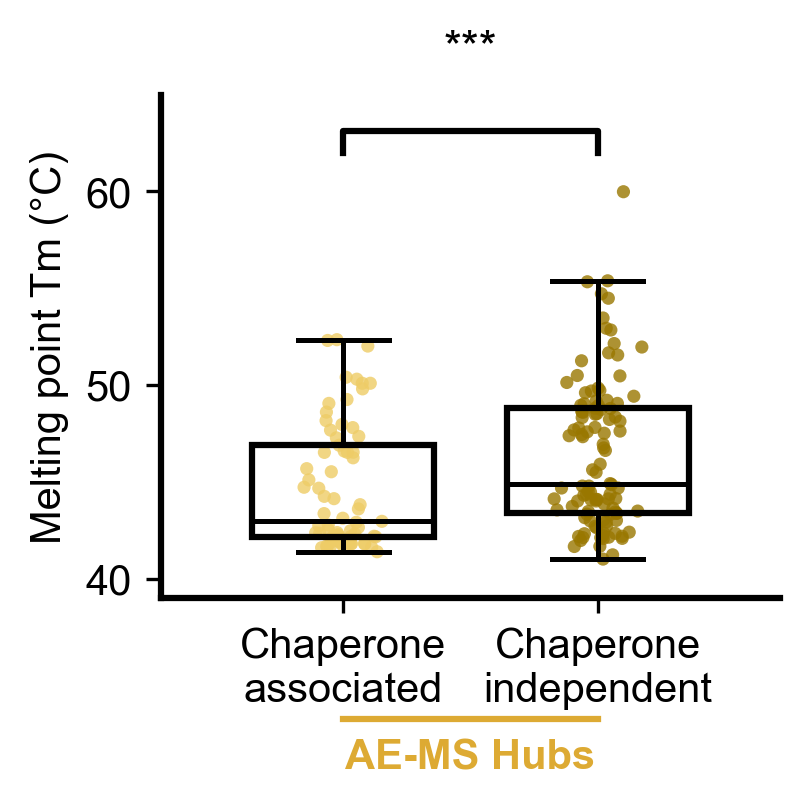

In [48]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\nassociated", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Melting point Tm (°C)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = 35     # a little below the real minimum
y_max = 60     # enough headroom for the bracket
ax.set_ylim(y_min, y_max)
ax.set_yticks([40, 50, 60])          # ← forces exactly these ticks
ax.set_yticklabels([40, 50, 60])
#y_min = min(hub_chap.min(), hub_nochap.min())
#y_max = max(hub_chap.max(), hub_nochap.max())

# Significance bracket slightly above the highest data point
bracket_y = 62

# IMPORTANT: set ylim AFTER computing bracket_y
#ax.set_ylim(y_min * 1.05, bracket_y + 8)
ax.set_ylim(39, 65) 

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.24, -0.24],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.35, -0.28, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6b-4.svg")
plt.show()

Boxplot of Turnover kinetics (t1/2 min) of chaperone associated hubs and chaperone independent hubs

In [49]:
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (degree-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

halflife_hub_chap     = hub_df[hub_df["has_chaperone"] == True]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
halflife_hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", halflife_hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", halflife_hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 73903.56it/s]


Hub + Chaperone: median=91.80, 95% CI=(91.20, 92.40), n=67)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 75863.21it/s]

Hub + No Chaperone: median=88.80, 95% CI=(77.40, 91.20), n=157)


In [50]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(halflife_hub_chap, halflife_hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on Villen_halflife_min ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(halflife_hub_chap)}, n(nochap) = {len(halflife_hub_nochap)}")
print(f"median(chap) = {np.median(halflife_hub_chap):.2f}, median(nochap) = {np.median(halflife_hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Villen_halflife_min ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 67, n(nochap) = 157
median(chap) = 91.80, median(nochap) = 88.80
U = 6196.50, p = 0.03492


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_41760/3140047687.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


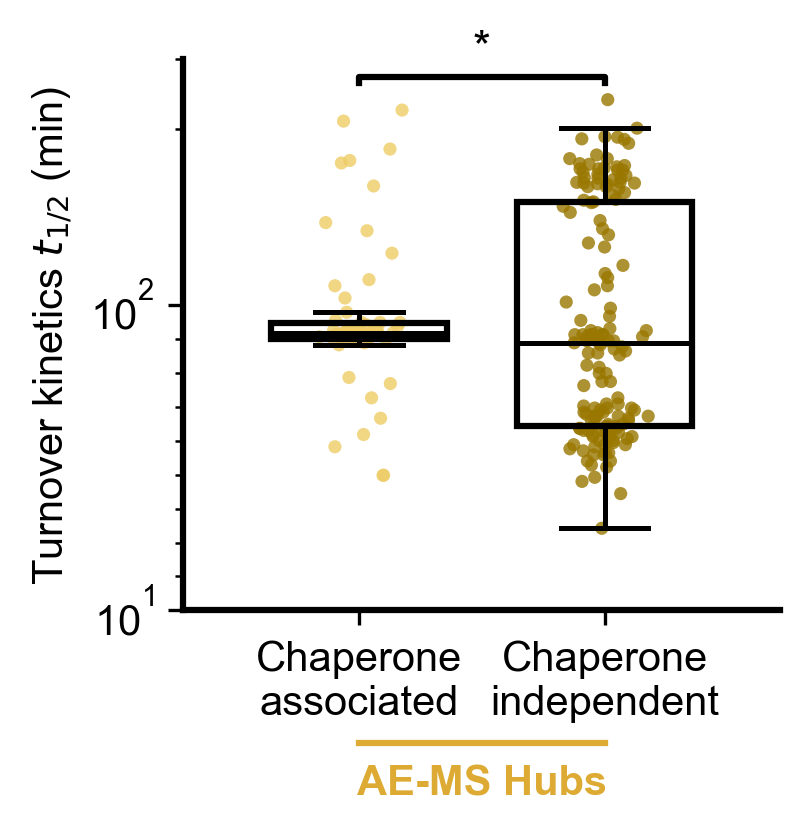

In [51]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 10
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top + 10,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [halflife_hub_chap, halflife_hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\nassociated", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)
        
#ax.set_yscale("log")
# Correct log ticks (10^1, 10^2, 10^3...)
#ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
#ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
#ax.yaxis.set_minor_locator(ticker.NullLocator())


# --- LOG SCALE with compressed bottom ---
ax.set_yscale("symlog", linthresh=130)
ax.set_ylim(10, 300)

ax.yaxis.set_major_locator(ticker.LogLocator(base=10))

ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=range(2, 10), numticks=12))


# --- Axes styling ---
ax.set_ylabel("Turnover kinetics $t_{1/2}$ (min)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)


# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(halflife_hub_chap.min(), halflife_hub_nochap.min())
y_max = max(halflife_hub_chap.max(), halflife_hub_nochap.max())

# Significance bracket slightly above the highest data point
bracket_y = 260

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(10, 300)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "*")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.24, -0.24],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.35, -0.28, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6b-5.svg")
plt.show()

Boxplot of Turnover kinetics (t1/2 min) of chaperone associated static and dynamic hubss

In [52]:
# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")
 
# Bootstrapped medians 
print("\n=== Bootstrapped median half-life (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f}, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 21
Static + NoChap   : n = 102
Dynamic + Chap    : n = 46
Dynamic + NoChap  : n = 55

=== Bootstrapped median half-life (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 69583.37it/s]


Static + Chap     : median = 91.8 min, 95% CI = (91.2, 105.6)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 80639.66it/s]


Static + NoChap   : median = 90.6 min, 95% CI = (81.6, 117.0)


Bootstrapping medians: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [19:52<00:00, 838.37it/s]


Dynamic + Chap    : median = 91.2 min, 95% CI = (90.6, 92.4)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 73815.74it/s]

Dynamic + NoChap  : median = 72.6 min, 95% CI = (63.6, 90.0)


In [53]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1256.0, p=0.215, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=1751.5, p=0.000908, significance=***
Static+Chap vs Dynamic+Chap   : U=611.5, p=0.0829, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=3744.5, p=0.00055, significance=***


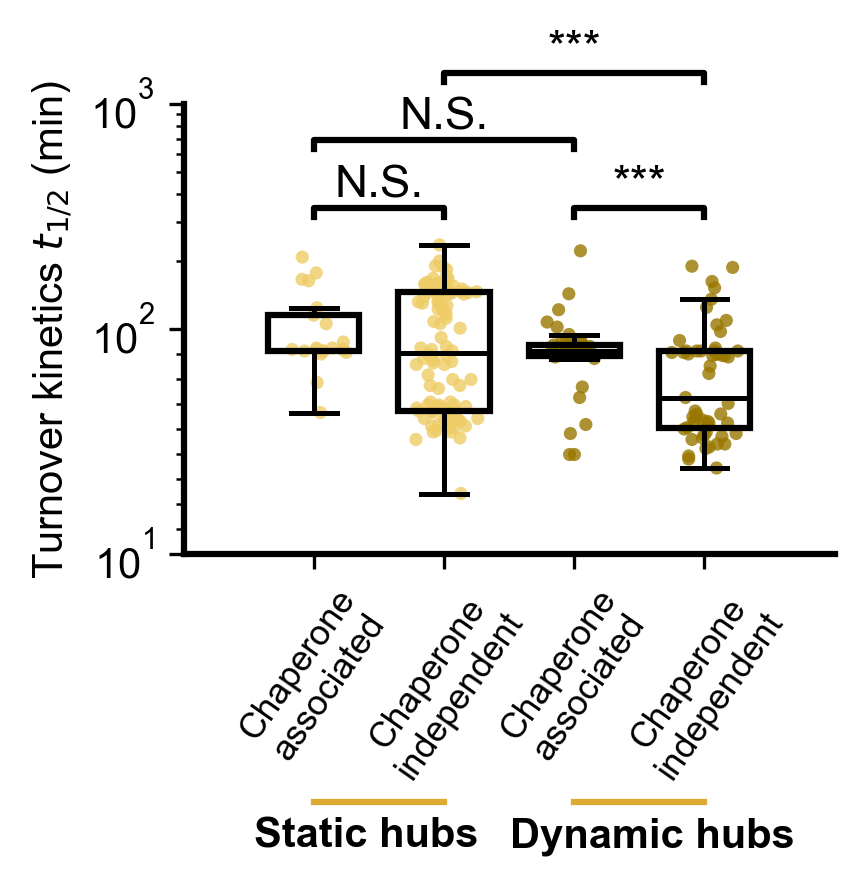

In [54]:
def add_bracket_axis(ax, x1, x2, y_axis, text):
    """
    Draw a bracket in AXIS coordinates.
    y_axis is a fraction of axis height (1.0 = top of plot).
    """
    trans = ax.get_xaxis_transform()  # x = data coords, y = axis coords (0–1)

    # bracket lines
    ax.plot([x1, x1, x2, x2],
            [y_axis, y_axis + 0.02, y_axis + 0.02, y_axis],
            transform=trans,
            lw=1.5, color="black", clip_on=False)

    # label
    ax.text((x1 + x2) / 2, y_axis + 0.025, text,
            transform=trans,
            ha="center", va="bottom",
            fontsize=11, clip_on=False)


fig, ax = plt.subplots(figsize=(2.8, 3))

positions = [0.7, 1.2, 1.7, 2.2]

group_data   = [static_chap, static_nochap, dynamic_chap, dynamic_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_LIGHT, MS_COLOR_DARK, MS_COLOR_DARK]
group_labels = [
    "Chaperone\nassociated",
    "Chaperone\nindependent",
    "Chaperone\nassociated",
    "Chaperone\nindependent"
]

ax.set_xticks(positions)
ax.set_xticklabels(
    ["Chaperone\nassociated",
     "Chaperone\nindependent",
     "Chaperone\nassociated",
     "Chaperone\nindependent"],
    fontsize=10
)

# SCATTER 
for pos, (vals, color) in zip(positions, zip(group_data, group_colors)):
    jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        jitter, vals,
        s=10,
        alpha=0.8,          
        color=color,
        edgecolor="none",
        zorder=2
    )

# BOXPLOTS 
bp = ax.boxplot(
    group_data,
    positions=positions,
    widths=0.35,           
    patch_artist=True,
    showfliers=False
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# Y-AXIS STYLE 
ax.set_yscale("symlog", linthresh=100)
ax.set_ylim(10, 1000)
ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10), numticks=999))

ax.set_ylabel(r'Turnover kinetics $t_{1/2}$ (min)', fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

ax.set_xticks(positions)
ax.set_xticklabels(group_labels, fontsize=8.5, ha="center", rotation=55)

#AXIS-BASED SIGNIFICANCE BRACKETS
# lowest brackets (pairwise)
add_bracket_axis(ax, positions[0], positions[1], 0.75, stars_static)
add_bracket_axis(ax, positions[2], positions[3], 0.75, stars_dynamic)

# middle bracket (cross-chaperone)
add_bracket_axis(ax, positions[0], positions[2], 0.9, stars_chap)

# top bracket (cross-independent)
add_bracket_axis(ax, positions[1], positions[3], 1.05, stars_nochap)

# GROUP LABELS AT BOTTOM 
trans = ax.get_xaxis_transform()

ax.plot(
    [0.7, 1.2], [-0.55, -0.55], transform=trans, clip_on=False, color=MS_COLOR, lw=1.5)
ax.text(0.9, -0.65, "Static hubs",
        transform=trans, ha="center", fontsize=10, fontweight="bold")

ax.plot(
    [1.7, 2.2], [-0.55, -0.55], transform=trans, clip_on=False, color=MS_COLOR, lw=1.5)
ax.text(2.0, -0.65, "Dynamic hubs",
        transform=trans, ha="center", fontsize=10, fontweight="bold")

plt.subplots_adjust(bottom=0.38)
plt.savefig(f"{OUT_PATH}6c-1.svg", dpi=300, bbox_inches="tight")
plt.show()

In [55]:
# Prepare Static/Dynamic + Chaperone Groups for Turnover t1/2

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Filter Meltome to high-confidence fits
hub_df = hub_df[hub_df["meltome-fit-R2"] > 0.9].copy()

# Convert meltome to numeric and clean
hub_df["meltome-melting-point"] = pd.to_numeric(
    hub_df["meltome-melting-point"], errors="coerce"
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")


# ================================================================
# Bootstrapped medians (boss-style)
# ================================================================
print("\n=== Bootstrapped median meltome-melting-point (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} °C, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 21
Static + NoChap   : n = 61
Dynamic + Chap    : n = 48
Dynamic + NoChap  : n = 48

=== Bootstrapped median meltome-melting-point (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 72113.98it/s]


Static + Chap     : median = 45.7 °C, 95% CI = (42.3, 47.4)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 73976.83it/s]


Static + NoChap   : median = 47.4 °C, 95% CI = (44.7, 48.7)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 70733.93it/s]


Dynamic + Chap    : median = 42.7 °C, 95% CI = (42.2, 44.2)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 70044.97it/s]

Dynamic + NoChap  : median = 44.1 °C, 95% CI = (43.3, 46.6)


In [56]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=454.5, p=0.0488, significance=*
Dynamic+Chap vs Dynamic+NoChap: U=886.5, p=0.0522, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=582.5, p=0.309, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=1909.0, p=0.00666, significance=**


In [57]:
# Prepare Static/Dynamic + Chaperone Groups

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Rosetta score column ONCE
hub_df["Rosetta_best_total_score"] = (
    pd.to_numeric(hub_df["Rosetta_best_total_score"], errors='coerce')
      .replace([np.inf, -np.inf], np.nan)
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")


# ================================================================
# Bootstrapped medians (boss-style)
# ================================================================
print("\n=== Bootstrapped median Rosetta_best_total_score (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} kcal/mol, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 26
Static + NoChap   : n = 108
Dynamic + Chap    : n = 56
Dynamic + NoChap  : n = 62

=== Bootstrapped median Rosetta_best_total_score (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 71146.21it/s]


Static + Chap     : median = -779.1 kcal/mol, 95% CI = (-1260.1, -348.9)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 80323.18it/s]


Static + NoChap   : median = -749.3 kcal/mol, 95% CI = (-910.1, -653.0)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 72602.45it/s]


Dynamic + Chap    : median = -493.5 kcal/mol, 95% CI = (-584.1, -428.0)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 75284.75it/s]

Dynamic + NoChap  : median = -728.1 kcal/mol, 95% CI = (-821.1, -557.6)


In [58]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1454.0, p=0.781, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=2040.0, p=0.102, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=575.0, p=0.129, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=2951.0, p=0.199, significance=N.S.


In [59]:
# Prepare Static/Dynamic + Chaperone Groups for Turnover t1/2

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Rosetta score column ONCE
hub_df["cagiada-dG"] = (
    pd.to_numeric(hub_df["cagiada-dG"], errors='coerce')
      .replace([np.inf, -np.inf], np.nan)
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")


# ================================================================
# Bootstrapped medians (boss-style)
# ================================================================
print("\n=== Bootstrapped median cagiada-dG (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} kcal/mol, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 26
Static + NoChap   : n = 108
Dynamic + Chap    : n = 56
Dynamic + NoChap  : n = 62

=== Bootstrapped median cagiada-dG (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 71221.83it/s]


Static + Chap     : median = -14.3 kcal/mol, 95% CI = (-24.4, -9.6)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 80375.79it/s]


Static + NoChap   : median = -13.5 kcal/mol, 95% CI = (-16.2, -11.3)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 75286.29it/s]


Dynamic + Chap    : median = -9.2 kcal/mol, 95% CI = (-10.3, -7.1)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74601.73it/s]

Dynamic + NoChap  : median = -12.4 kcal/mol, 95% CI = (-13.2, -9.2)


In [60]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1281.0, p=0.491, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=1942.0, p=0.268, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=521.0, p=0.0396, significance=*
Static+NoChap vs Dynamic+NoChap: U=2823.0, p=0.0895, significance=N.S.


In [61]:
# Prepare Static/Dynamic + Chaperone Groups for Turnover t1/2

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Rosetta score column ONCE
hub_df["Ghosh-Dill-dG"] = (
    pd.to_numeric(hub_df["Ghosh-Dill-dG"], errors='coerce')
      .replace([np.inf, -np.inf], np.nan)
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")


# ================================================================
# Bootstrapped medians (boss-style)
# ================================================================
print("\n=== Bootstrapped median meltome-melting-point (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} °C, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 26
Static + NoChap   : n = 108
Dynamic + Chap    : n = 56
Dynamic + NoChap  : n = 62

=== Bootstrapped median meltome-melting-point (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 72051.30it/s]


Static + Chap     : median = -9.0 °C, 95% CI = (-11.0, -6.2)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 80256.05it/s]


Static + NoChap   : median = -8.8 °C, 95% CI = (-10.0, -8.3)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 72523.02it/s]


Dynamic + Chap    : median = -7.0 °C, 95% CI = (-8.0, -6.7)


Bootstrapping medians: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74260.83it/s]

Dynamic + NoChap  : median = -8.1 °C, 95% CI = (-8.5, -7.3)


In [62]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1542.5, p=0.437, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=2010.0, p=0.14, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=606.0, p=0.226, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=2733.5, p=0.0468, significance=*


In [63]:
import pandas as pd
import ast

# ----------------------------------------------------------
# STEP 1 — Filter Hubs Only
# ----------------------------------------------------------
hub_df = final_df[final_df["is_hub"] == True].copy()

# ----------------------------------------------------------
# STEP 2 — Expand chaperone info into long-format table
# ----------------------------------------------------------

rows = []

for idx, row in hub_df.iterrows():
    hub_type = row["hub_type"]         # static / dynamic
    info_cell = row["interacting_chaperone_info"]

    # Parse stringified lists (if needed)
    if isinstance(info_cell, str):
        try:
            info_cell = ast.literal_eval(info_cell)
        except:
            info_cell = None

    # Skip if empty or NaN
    if not isinstance(info_cell, list):
        continue

    # Extract each chaperone annotation
    for chap in info_cell:
        rows.append({
            "protein": row["node"],                           
            "hub_type": hub_type,
            "chaperone_orf": chap.get("ORF"),
            "chaperone_family": chap.get("CCo Family"),
            "chaperone_name": chap.get("Name description")
        })

# Long-format dataframe
chaps_long = pd.DataFrame(rows)

print("=== Long-format chaperone annotation (first 10 rows) ===")
print(chaps_long.head(10))

=== Long-format chaperone annotation (first 10 rows) ===
   protein hub_type chaperone_orf chaperone_family  \
0  YBR149W  dynamic       YKL117W  Hsp90 cofactors   
1  YDR037W  dynamic       YGR285C            Hsp40   
2  YDR037W  dynamic       YER048C            Hsp40   
3  YDR037W  dynamic       YLR216C  Hsp90 cofactors   
4  YDR037W  dynamic       YHR064C            Hsp70   
5  YHR019C  dynamic       YGR285C            Hsp40   
6  YHR019C  dynamic       YER048C            Hsp40   
7  YHR019C  dynamic       YLR216C  Hsp90 cofactors   
8  YHR019C  dynamic       YHR064C            Hsp70   
9  YLL018C  dynamic       YLR216C  Hsp90 cofactors   

                                     chaperone_name  
0  increased Sensitivity to Benzoquinone Ansamycins  
1                                            ZUOtin  
2                        DnaK-like protein of yeast  
3            Cyclosporin-sensitive Proline Rotamase  
4          Stress-Seventy that interacts with Zuo1p  
5                       

In [64]:
#Get Summary Table: Static vs Dynamic Side-by-Side
family_pivot = family_counts.pivot(index="chaperone_family",
                                   columns="hub_type",
                                   values="count").fillna(0)

family_pivot["total"] = family_pivot.sum(axis=1)

print("\n=== Static vs Dynamic Chaperone Enrichment ===")
print(family_pivot.sort_values("total", ascending=False))

NameError: name 'family_counts' is not defined

In [65]:
#Normalize chaperone-family counts per hub type
# Count number of hubs in each category
n_static  = hub_df[hub_df["hub_type"] == "static"]["node"].nunique()
n_dynamic = hub_df[hub_df["hub_type"] == "dynamic"]["node"].nunique()

print("Static hubs:", n_static)
print("Dynamic hubs:", n_dynamic)

# Count raw interactions per family
family_counts = (
    chaps_long.groupby(["hub_type", "chaperone_family"])
              .size()
              .reset_index(name="count")
)

# Add normalization
family_counts["normalized_frequency"] = family_counts.apply(
    lambda r: r["count"] / (n_static if r["hub_type"] == "static" else n_dynamic),
    axis=1
)

print("\n=== Normalized chaperone-family counts ===")
print(family_counts)

Static hubs: 134
Dynamic hubs: 118

=== Normalized chaperone-family counts ===
   hub_type  chaperone_family  count  normalized_frequency
0   dynamic              AAA+      2              0.016949
1   dynamic               CCT      1              0.008475
2   dynamic             Hsp40     81              0.686441
3   dynamic             Hsp60      2              0.016949
4   dynamic             Hsp70     31              0.262712
5   dynamic   Hsp70 cofactors      1              0.008475
6   dynamic             Hsp90      2              0.016949
7   dynamic   Hsp90 cofactors      6              0.050847
8    static              AAA+      8              0.059701
9    static               CCT      3              0.022388
10   static             Hsp10      2              0.014925
11   static             Hsp40     32              0.238806
12   static             Hsp60      3              0.022388
13   static             Hsp70     29              0.216418
14   static   Hsp70 cofactors      4

In [66]:
#Fisher Exact Test for EACH chaperone family
from scipy.stats import fisher_exact
import pandas as pd

# Start a results table
fisher_results = []

families = chaps_long["chaperone_family"].unique()

for fam in families:
    # Hubs that interact with this family
    dyn_yes = chaps_long[(chaps_long["hub_type"] == "dynamic") &
                         (chaps_long["chaperone_family"] == fam)]["protein"].nunique()
    stat_yes = chaps_long[(chaps_long["hub_type"] == "static") &
                          (chaps_long["chaperone_family"] == fam)]["protein"].nunique()

    # Hubs that do NOT interact with this family
    dyn_no = n_dynamic - dyn_yes
    stat_no = n_static - stat_yes

    table = [[dyn_yes, dyn_no],
             [stat_yes, stat_no]]

    OR, p = fisher_exact(table)

    fisher_results.append({
        "family": fam,
        "dynamic_yes": dyn_yes,
        "static_yes": stat_yes,
        "odds_ratio": OR,
        "p_value": p
    })

fisher_df = pd.DataFrame(fisher_results).sort_values("p_value")
print("\n=== Fisher enrichment results ===")
print(fisher_df)



=== Fisher enrichment results ===
             family  dynamic_yes  static_yes  odds_ratio       p_value
1             Hsp40           55          20    4.976190  4.494434e-08
2             Hsp70           28          13    2.895726  3.386585e-03
6              AAA+            1           6    0.182336  1.250825e-01
9  Small heat shock            0           3    0.000000  2.500474e-01
3   Hsp70 cofactors            1           4    0.277778  3.750998e-01
5             Hsp90            1           4    0.277778  3.750998e-01
8             Hsp10            0           2    0.000000  5.000316e-01
7               CCT            1           3    0.373219  6.250599e-01
0   Hsp90 cofactors            6           5    1.382143  7.596576e-01
4             Hsp60            2           3    0.752874  1.000000e+00


In [67]:
#Generate a clean summary table (easy to export)
summary = family_counts.pivot(index="chaperone_family",
                              columns="hub_type",
                              values="normalized_frequency")

summary["Fisher_p"] = summary.index.map(
    dict(zip(fisher_df["family"], fisher_df["p_value"]))
)

print("\n=== Final Summary Table ===")
print(summary)


=== Final Summary Table ===
hub_type           dynamic    static      Fisher_p
chaperone_family                                  
AAA+              0.016949  0.059701  1.250825e-01
CCT               0.008475  0.022388  6.250599e-01
Hsp10                  NaN  0.014925  5.000316e-01
Hsp40             0.686441  0.238806  4.494434e-08
Hsp60             0.016949  0.022388  1.000000e+00
Hsp70             0.262712  0.216418  3.386585e-03
Hsp70 cofactors   0.008475  0.029851  3.750998e-01
Hsp90             0.016949  0.052239  3.750998e-01
Hsp90 cofactors   0.050847  0.059701  7.596576e-01
Small heat shock       NaN  0.037313  2.500474e-01


<Figure size 1800x1140 with 0 Axes>

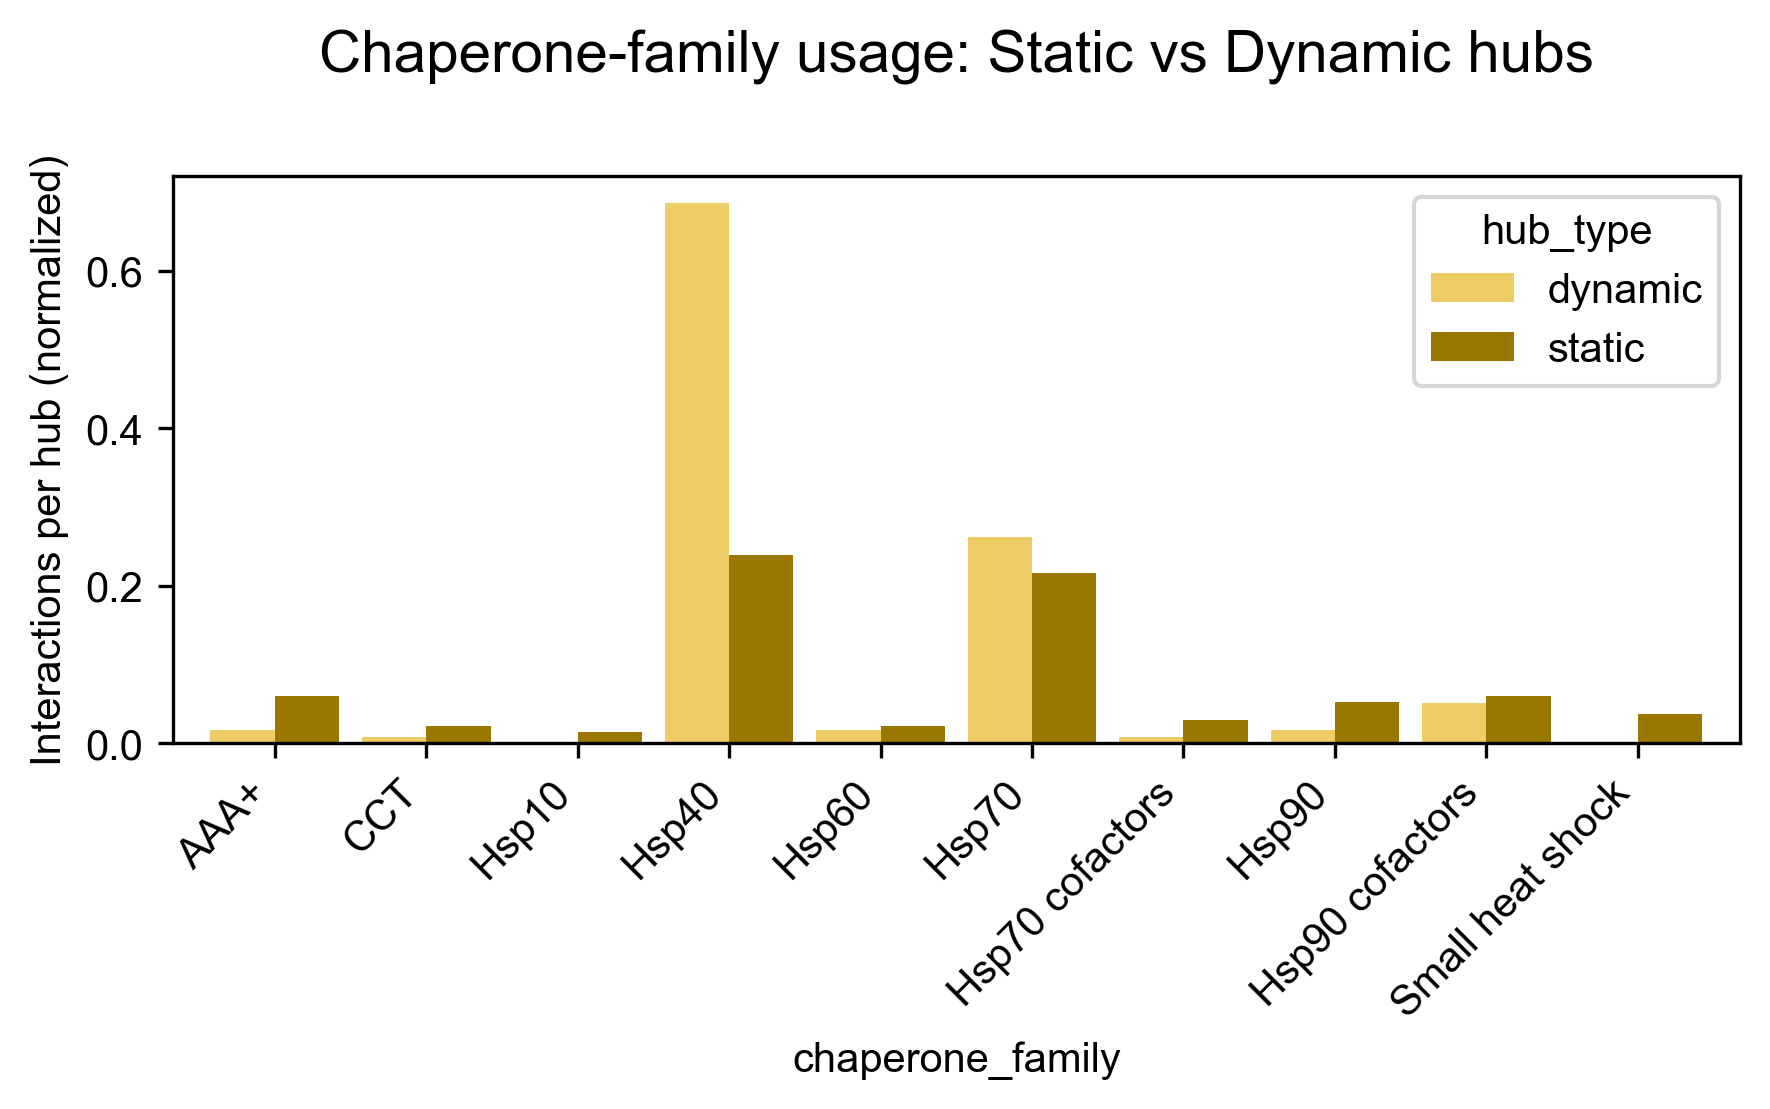

In [68]:
summary = family_counts.pivot(index="chaperone_family",
                              columns="hub_type",
                              values="normalized_frequency").fillna(0)

summary = summary.loc[summary.index]  # keep order

plt.figure(figsize=(6, 3.8))

summary.plot(kind="bar",
             figsize=(6, 3.8),
             color=[MS_COLOR_LIGHT, MS_COLOR_DARK],
             width=0.85)

plt.ylabel("Interactions per hub (normalized)")
plt.title("Chaperone-family usage: Static vs Dynamic hubs")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [69]:
# 0. Long-format chaperone table for hubs

# Keep only hubs
hub_df = final_df[final_df["is_hub"] == True].copy()

rows = []
for _, row in hub_df.iterrows():
    hub_type = row["hub_type"]             # 'static' / 'dynamic'
    info_list = row["interacting_chaperone_info"]
    
    if isinstance(info_list, list):
        for chap in info_list:
            rows.append({
                "protein":         row["node"],                 # hub protein
                "hub_type":        hub_type,
                "chaperone_orf":   chap.get("ORF"),
                "chaperone_family":chap.get("CCo Family"),
                "chaperone_name":  chap.get("Name description")
            })

chaps_long = pd.DataFrame(rows).dropna(subset=["chaperone_orf"])

print("=== Long-format chaperone annotation (first 10 rows) ===")
print(chaps_long.head(10))

=== Long-format chaperone annotation (first 10 rows) ===
   protein hub_type chaperone_orf chaperone_family  \
0  YBR149W  dynamic       YKL117W  Hsp90 cofactors   
1  YDR037W  dynamic       YGR285C            Hsp40   
2  YDR037W  dynamic       YER048C            Hsp40   
3  YDR037W  dynamic       YLR216C  Hsp90 cofactors   
4  YDR037W  dynamic       YHR064C            Hsp70   
5  YHR019C  dynamic       YGR285C            Hsp40   
6  YHR019C  dynamic       YER048C            Hsp40   
7  YHR019C  dynamic       YLR216C  Hsp90 cofactors   
8  YHR019C  dynamic       YHR064C            Hsp70   
9  YLL018C  dynamic       YLR216C  Hsp90 cofactors   

                                     chaperone_name  
0  increased Sensitivity to Benzoquinone Ansamycins  
1                                            ZUOtin  
2                        DnaK-like protein of yeast  
3            Cyclosporin-sensitive Proline Rotamase  
4          Stress-Seventy that interacts with Zuo1p  
5                       

1️⃣ Construct the Chaperone–Hub Network (bipartite graph)

We’ll build a bipartite networkx graph:

One node set = hubs (protein), with attribute hub_type

Other node set = chaperones (chaperone_orf), with attributes family, name

Edges = interactions

In [70]:
#Construct the Chaperone–Hub Network (bipartite graph)
import networkx as nx

# 1. Build bipartite graph
B = nx.Graph()

# -- Add hub nodes --
for prot, htype in hub_df[["node", "hub_type"]].drop_duplicates().itertuples(index=False):
    B.add_node(
        prot,
        bipartite="hub",
        hub_type=htype
    )

# -- Add chaperone nodes (unique ORFs) --
for orf, fam, name in chaps_long[["chaperone_orf", "chaperone_family", "chaperone_name"]].drop_duplicates().itertuples(index=False):
    B.add_node(
        orf,
        bipartite="chaperone",
        family=fam,
        name=name
    )

# -- Add edges hub ↔ chaperone --
for _, r in chaps_long.iterrows():
    B.add_edge(r["protein"], r["chaperone_orf"])

print(f"Total nodes in bipartite graph: {B.number_of_nodes()}")
print(f"  Hubs:        {sum(1 for n,d in B.nodes(data=True) if d.get('bipartite')=='hub')}")
print(f"  Chaperones:  {sum(1 for n,d in B.nodes(data=True) if d.get('bipartite')=='chaperone')}")
print(f"Total edges (hub–chaperone interactions): {B.number_of_edges()}")

Total nodes in bipartite graph: 287
  Hubs:        248
  Chaperones:  39
Total edges (hub–chaperone interactions): 225


Identify hub-specialist chaperones (per chaperone ORF)

Now we ask: For each chaperone ORF, how many static vs dynamic hubs does it bind?

We’ll:

Count static / dynamic hubs per chaperone

Compute fractions and log₂(dynamic/static)

Optionally a Fisher test vs background (all other chaperones)

In [71]:
from scipy.stats import fisher_exact
import numpy as np

# 2A. Counts of static/dynamic hubs per chaperone
chap_pref = (
    chaps_long
    .groupby(["chaperone_orf", "chaperone_family", "chaperone_name", "hub_type"])
    .size()
    .unstack(fill_value=0)  # columns: static, dynamic (hopefully)
    .reset_index()
)

# Ensure columns exist even if no static/dynamic for some
for col in ["static", "dynamic"]:
    if col not in chap_pref.columns:
        chap_pref[col] = 0

chap_pref["total"] = chap_pref["static"] + chap_pref["dynamic"]

# 2B. Global totals (for Fisher background)
global_counts = (
    chaps_long
    .groupby("hub_type")
    .size()
    .reindex(["dynamic", "static"], fill_value=0)
)
total_dynamic = global_counts["dynamic"]
total_static  = global_counts["static"]

results = []

for _, row in chap_pref.iterrows():
    dyn_yes = row["dynamic"]
    stat_yes = row["static"]
    
    # others = everything except this chaperone
    dyn_no = total_dynamic - dyn_yes
    stat_no = total_static - stat_yes
    
    # contingency: [[dynamic_yes, dynamic_no], [static_yes, static_no]]
    table = [[dyn_yes, dyn_no],
             [stat_yes, stat_no]]
    
    # Two-sided Fisher
    odds, p = fisher_exact(table, alternative="two-sided")
    
    # log2 preference (add small epsilon to avoid log(0))
    eps = 1e-6
    frac_dyn = (dyn_yes + eps) / (dyn_yes + stat_yes + 2*eps)
    frac_stat = (stat_yes + eps) / (dyn_yes + stat_yes + 2*eps)
    log2_dyn_over_static = np.log2(frac_dyn / frac_stat)
    
    results.append({
        "chaperone_orf": row["chaperone_orf"],
        "family": row["chaperone_family"],
        "name": row["chaperone_name"],
        "dynamic_yes": dyn_yes,
        "static_yes": stat_yes,
        "total_hubs_bound": row["total"],
        "odds_ratio": odds,
        "p_value": p,
        "log2_dyn_over_static": log2_dyn_over_static,
        "frac_dynamic": frac_dyn,
        "frac_static": frac_stat,
    })

chap_enrichment = pd.DataFrame(results)

# Sort by p or by log2 preference, e.g. most dynamic-preferring, significant
chap_enrichment_sorted = chap_enrichment.sort_values("p_value")

print("=== Top chaperones by enrichment p-value ===")
print(chap_enrichment_sorted.head(15))

print("\n=== Strong dynamic-preferring chaperones (log2_dyn_over_static > 1, p<0.05) ===")
print(chap_enrichment_sorted.query("log2_dyn_over_static > 1 and p_value < 0.05"))


=== Top chaperones by enrichment p-value ===
   chaperone_orf            family                                      name  \
31       YNL227C             Hsp40                      J-protein (Type III)   
14       YHR064C             Hsp70  Stress-Seventy that interacts with Zuo1p   
13       YGR285C             Hsp40                                    ZUOtin   
30       YNL209W             Hsp70                Stress-Seventy subfamily B   
10       YER103W             Hsp70                Stress-Seventy subfamily A   
37       YPL235W              AAA+                                 RuVB-like   
15       YJL008C               CCT               Chaperonin Containing TCP-1   
6        YDR171W  Small heat shock                        Heat Shock Protein   
29       YNL064C             Hsp40                                Yeast dnaJ   
38       YPL240C             Hsp90                     Heat Shock Protein 82   
20       YLL024C             Hsp70                Stress-Seventy subfamily 

Cluster hubs based on chaperone-binding profiles

Here we treat each hub as a vector of “binds Hsp40? Hsp70? …” etc.

We’ll do it per family (not per ORF) so dimensionality stays small.

3A. Build hub × family matrix

In [72]:
# Hub × Family matrix (counts, can also binarize)
hub_family = (
    chaps_long
    .groupby(["protein", "hub_type", "chaperone_family"])
    .size()
    .unstack(fill_value=0)
)

print("=== Hub × Family matrix (first 5 rows) ===")
print(hub_family.head())

=== Hub × Family matrix (first 5 rows) ===
chaperone_family  AAA+  CCT  Hsp10  Hsp40  Hsp60  Hsp70  Hsp70 cofactors  \
protein hub_type                                                           
YAL005C static       1    1      1      3      1      7                1   
YAL035W dynamic      0    0      0      1      0      0                0   
YAL038W static       0    0      0      1      0      3                0   
YBL002W static       2    0      0      0      0      0                0   
YBL003C static       1    0      0      0      0      0                0   

chaperone_family  Hsp90  Hsp90 cofactors  Small heat shock  
protein hub_type                                            
YAL005C static        2                2                 2  
YAL035W dynamic       0                0                 0  
YAL038W static        1                0                 2  
YBL002W static        0                0                 0  
YBL003C static        0                0                 0

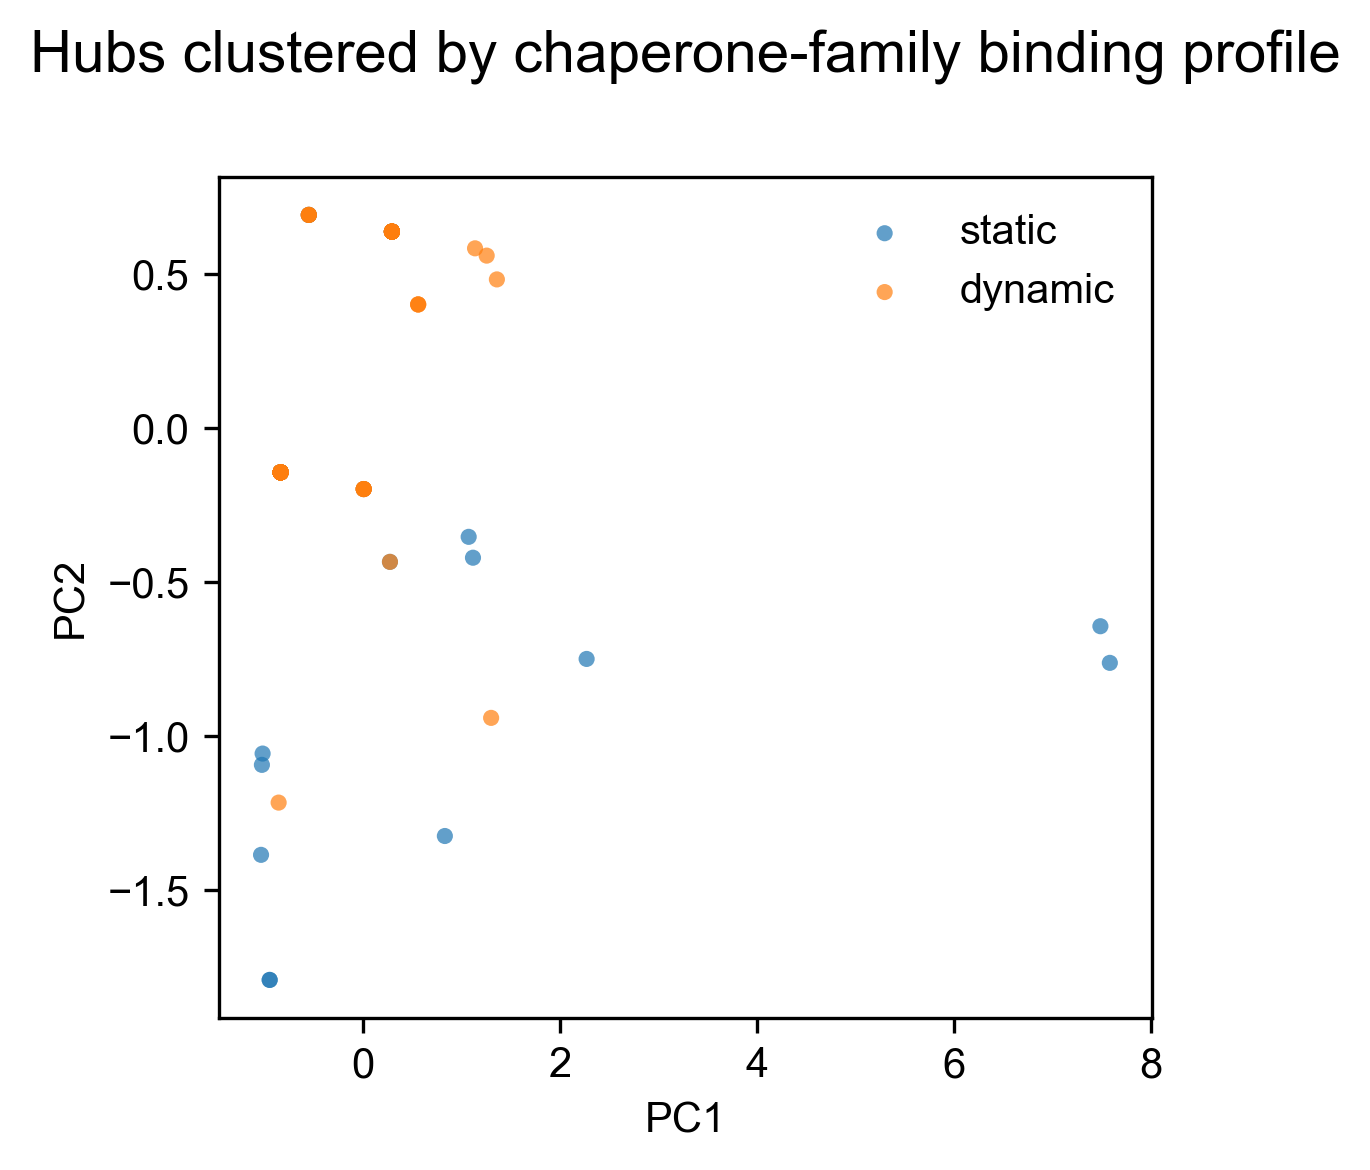

In [73]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Separate features & labels
X = hub_family.values     # or hub_family_binary.values
hub_labels = hub_family.index.get_level_values("hub_type")  # 'static'/'dynamic'
hub_ids = hub_family.index.get_level_values("protein")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(4,4))
for htype, color in [("static", "tab:blue"), ("dynamic", "tab:orange")]:
    mask = (hub_labels == htype)
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=15,
        alpha=0.7,
        label=htype,
        edgecolors="none",
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hubs clustered by chaperone-family binding profile")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Build a chaperone-centric network map

Let’s make a nice, interpretable subnetwork:

Keep only chaperones that bind at least k hubs (say 5)

Keep only hubs that have at least one of these “top chaperones”

Draw:

chaperones as squares, colored by family, sized by # hubs

hubs as circles, colored by static/dynamic

In [ ]:
# How many hubs does each chaperone bind?
chap_hub_counts = (
    chaps_long[["chaperone_orf", "protein"]]
    .drop_duplicates()
    .groupby("chaperone_orf")
    .size()
    .reset_index(name="n_hubs")
)

# Take chaperones binding at least k hubs
k = 5
top_chaps = chap_hub_counts[chap_hub_counts["n_hubs"] >= k]["chaperone_orf"].tolist()
print(f"Number of chaperones binding ≥{k} hubs: {len(top_chaps)}")

In [ ]:
# Nodes we keep: those chaperones and the hubs they touch
nodes_to_keep = set(top_chaps)

for orf in top_chaps:
    if orf in B:
        neighbors = B.neighbors(orf)
        for h in neighbors:
            nodes_to_keep.add(h)

subB = B.subgraph(nodes_to_keep).copy()
print(f"Subgraph: {subB.number_of_nodes()} nodes, {subB.number_of_edges()} edges")

In [ ]:
#chaperone centric network
# Separate bipartite sets for layout & styling
hub_nodes = [n for n,d in subB.nodes(data=True) if d.get("bipartite") == "hub"]
chap_nodes = [n for n,d in subB.nodes(data=True) if d.get("bipartite") == "chaperone"]

# Simple layout: project to 2D with spring_layout
pos = nx.spring_layout(subB, seed=42, k=0.4, iterations=200)

plt.figure(figsize=(6,6))

# --- Hubs ---
hub_colors = []
for n in hub_nodes:
    htype = subB.nodes[n].get("hub_type")
    if htype == "static":
        hub_colors.append("tab:blue")
    elif htype == "dynamic":
        hub_colors.append("tab:orange")
    else:
        hub_colors.append("0.7")  # grey fallback

nx.draw_networkx_nodes(
    subB,
    pos,
    nodelist=hub_nodes,
    node_size=40,
    node_color=hub_colors,
    alpha=0.8,
    edgecolors="none",
)

# --- Chaperones ---
# Size by number of hubs they bind in THIS subgraph
chap_sizes = []
chap_colors = []
family_color_map = {}  # color per family
palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, n in enumerate(chap_nodes):
    fam = subB.nodes[n].get("family", "other")
    if fam not in family_color_map:
        family_color_map[fam] = palette[len(family_color_map) % len(palette)]
    chap_colors.append(family_color_map[fam])
    
    # size by degree
    deg = subB.degree[n]
    chap_sizes.append(80 + 20*deg)

nx.draw_networkx_nodes(
    subB,
    pos,
    nodelist=chap_nodes,
    node_size=chap_sizes,
    node_color=chap_colors,
    node_shape="s",
    alpha=0.9,
    edgecolors="black",
    linewidths=0.5,
)

# --- Edges ---
nx.draw_networkx_edges(
    subB,
    pos,
    width=0.5,
    alpha=0.4,
)

# Optional: label a few top chaperones
top_label_chaps = chap_hub_counts.sort_values("n_hubs", ascending=False).head(5)["chaperone_orf"].tolist()
labels = {n: n for n in chap_nodes if n in top_label_chaps}

nx.draw_networkx_labels(
    subB,
    pos,
    labels=labels,
    font_size=8,
)

plt.axis("off")
plt.title("Chaperone–Hub network (top chaperones by hub degree)")
plt.tight_layout()
plt.show()

print("Family → color mapping used:")
for fam, col in family_color_map.items():
    print(f"  {fam}: {col}")

In [ ]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import hypergeom

# --- Parse GO terms from columns ---
# Split semicolon-separated GO IDs
# Just to be safe: replace NaNs with empty strings
final_df["GO_terms"] = final_df["GO_terms"].fillna("")
final_df["GO_terms_human_readable"] = final_df["GO_terms_human_readable"].fillna("")

# Parse GO IDs into a Python list per protein ---
# Example: "GO:0005737;GO:0005937" → ["GO:0005737", "GO:0005937"]
final_df["GO_list"] = final_df["GO_terms"].apply(
    lambda s: [g.strip() for g in s.split(";") if g.strip() != ""]
)

# Parse human-readable mapping GO_ID -> name ---
# Handles formats like:
# "GO:0005737: cytoplasm;GO:0005886: plasma membrane"
def parse_readable_row(s):
    items = [x.strip() for x in s.split(";") if x.strip() != ""]
    mapping = {}
    for it in items:
        if not it.startswith("GO:"):
            continue
        # split only on the first two ":", so we can reconstruct GO:0005737
        parts = it.split(":", 2)  # e.g. ["GO","0005737"," cytoplasm"]
        if len(parts) >= 3:
            go_id = parts[0] + ":" + parts[1]   # "GO:0005737"
            name = parts[2].strip()
            mapping[go_id] = name
        elif len(parts) == 2:
            # case like "GO:0004127" with no name
            go_id = parts[0] + ":" + parts[1]
            mapping.setdefault(go_id, go_id)
    return mapping

final_df["GO_readable_dict"] = final_df["GO_terms_human_readable"].apply(parse_readable_row)

# Global map GO_ID -> name (so we can look up names later)
go_name_map = {}
for d in final_df["GO_readable_dict"]:
    go_name_map.update(d)

print("Example GO mapping (first 10):")
print(list(go_name_map.items())[:10])

In [ ]:
# Dynamic hubs with chaperone interactions
dynamic_chap = final_df[
    (final_df["hub_type"] == "dynamic") &
    (final_df["num_chaperone_interactions"] > 0)
].copy()

background = final_df.copy()

print("Dynamic+Chaperone n =", len(dynamic_chap))
all_terms = [t for lst in dynamic_chap["GO_list"] for t in lst]
print("Unique GO terms in Dynamic+Chaperone =", len(set(all_terms)))

go_enrich.sort_values("p_value").head(20)

In [ ]:
# --- 3A. Background GO counts ---
all_go_bg = []
for lst in background["GO_list"]:
    all_go_bg.extend(lst)
background_counts = pd.Series(all_go_bg).value_counts()

# --- 3B. Test GO counts (dynamic + chaperone) ---
all_go_test = []
for lst in dynamic_chap["GO_list"]:
    all_go_test.extend(lst)
test_counts = pd.Series(all_go_test).value_counts()

# We'll only test GO terms that appear at least 2 times in the test set
unique_go_terms = test_counts[test_counts >= 2].index

results = []
N = len(background)        # universe size
n = len(dynamic_chap)      # test set size

for go in unique_go_terms:
    K = background_counts.get(go, 0)   # count in background
    k = test_counts.get(go, 0)         # count in test set
    if K == 0:
        continue

    # hypergeometric P(X >= k)
    pval = hypergeom.sf(k - 1, N, K, n)
    fold = (k / n) / (K / N)

    # human-readable name from global map, fallback to GO ID
    readable = go_name_map.get(go, go)

    results.append([go, readable, k, K, fold, pval])

go_enrich = pd.DataFrame(
    results,
    columns=["GO_ID", "GO_name", "k_test", "K_background", "fold_enrichment", "p_value"]
)

print("Total GO terms tested:", len(go_enrich))

if len(go_enrich) == 0:
    print("No GO terms met the minimum criteria (freq >= 2 in test set).")
else:
    # FDR correction
    go_enrich["FDR"] = multipletests(go_enrich["p_value"], method="fdr_bh")[1]
    # sort by FDR and keep top 15
    go_sig = go_enrich.sort_values("FDR").head(15)
    print(go_sig)


In [ ]:
if len(go_enrich) > 0:

    plot_df = go_enrich.sort_values("FDR").head(15).copy()
    plot_df["neglog10FDR"] = -np.log10(plot_df["FDR"] + 1e-12)

    # Use human-readable name when available, otherwise GO ID
    plot_df["label"] = plot_df.apply(
        lambda r: r["GO_name"] if pd.notna(r["GO_name"]) and r["GO_name"] != "" else r["GO_ID"],
        axis=1
    )

    fig, ax = plt.subplots(figsize=(4, 5))

    scatter = ax.scatter(
        plot_df["fold_enrichment"],
        plot_df["label"],
        s=plot_df["k_test"] * 40,
        c=plot_df["neglog10FDR"],
        cmap="viridis",
        edgecolors="black",
        linewidth=0.6,
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("-log10(FDR)", fontsize=10)

    ax.set_xlabel("Fold enrichment", fontsize=11)
    ax.set_ylabel("GO term", fontsize=11)
    ax.set_title("GO Enrichment: Dynamic Hubs + Chaperone", fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{OUT_PATH}GO_dynamic_chap_dotplot.svg", dpi=300)
    plt.show()


In [ ]:
# Static hubs with ≥1 chaperone interaction
static_chap = final_df[
    (final_df["hub_type"] == "static") &
    (final_df["num_chaperone_interactions"] > 0)
].copy()

background = final_df.copy()

print("Static + Chaperone n =", len(static_chap))


In [ ]:
# --- Background GO counts ---
all_go_bg = []
for lst in background["GO_list"]:
    all_go_bg.extend(lst)
background_counts = pd.Series(all_go_bg).value_counts()

# --- Test GO counts ---
all_go_test = []
for lst in static_chap["GO_list"]:
    all_go_test.extend(lst)
test_counts = pd.Series(all_go_test).value_counts()

# Only GO terms appearing ≥2 times in test set
unique_go_terms = test_counts[test_counts >= 2].index

results = []
N = len(background)
n = len(static_chap)

for go in unique_go_terms:
    K = background_counts.get(go, 0)
    k = test_counts.get(go, 0)

    if K == 0:
        continue

    pval = hypergeom.sf(k - 1, N, K, n)
    fold = (k/n) / (K/N)

    # readable name from go_name_map
    readable = go_name_map.get(go, go)

    results.append([go, readable, k, K, fold, pval])

static_go = pd.DataFrame(
    results,
    columns=["GO_ID", "GO_name", "k_test", "K_background", "fold_enrichment", "p_value"]
)

if len(static_go) == 0:
    print("No GO terms met criteria.")
else:
    static_go["FDR"] = multipletests(static_go["p_value"], method="fdr_bh")[1]
    static_go_sig = static_go.sort_values("FDR").head(15)
    print(static_go_sig)


In [ ]:
if len(static_go) > 0:
    plot_df = static_go.sort_values("FDR").head(15).copy()
    plot_df["neglog10FDR"] = -np.log10(plot_df["FDR"] + 1e-12)

    plot_df["label"] = plot_df.apply(
        lambda r: r["GO_name"] if pd.notna(r["GO_name"]) and r["GO_name"] != "" else r["GO_ID"],
        axis=1
    )

    fig, ax = plt.subplots(figsize=(4, 5))

    scatter = ax.scatter(
        plot_df["fold_enrichment"],
        plot_df["label"],
        s = plot_df["k_test"] * 40,
        c = plot_df["neglog10FDR"],
        cmap="viridis",
        edgecolors="black",
        linewidth=0.6,
    )

    plt.colorbar(scatter, ax=ax).set_label("-log10(FDR)", fontsize=10)

    ax.set_xlabel("Fold enrichment", fontsize=11)
    ax.set_ylabel("GO term", fontsize=11)
    ax.set_title("GO Enrichment: Static Hubs + Chaperone", fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{OUT_PATH}GO_static_chap.svg", dpi=300)
    plt.show()


In [ ]:
ribosomal_go_ids = set()

for go_id, name in go_name_map.items():
    if name is None:
        continue
    text = name.lower()
    if (
        "ribosom" in text or
        "translation" in text or
        "ribonucleoprotein" in text or
        "r rna" in text or
        "rrna" in text or
        "structural constituent of ribosome" in text
    ):
        ribosomal_go_ids.add(go_id)

print("Identified ribosome-related GO IDs:", len(ribosomal_go_ids))


In [ ]:
def is_ribosomal(go_list):
    return any(go in ribosomal_go_ids for go in go_list)

# Mark ribosomal proteins
final_df["is_ribosomal"] = final_df["GO_list"].apply(is_ribosomal)

print("Total ribosomal proteins:", final_df["is_ribosomal"].sum())


In [ ]:
dynamic_chap_no_ribo = final_df[
    (final_df["hub_type"] == "dynamic") &
    (final_df["num_chaperone_interactions"] > 0) &
    (~final_df["is_ribosomal"])
].copy()

print("Dynamic+Chaperone (NO ribosomal) n =", len(dynamic_chap_no_ribo))


In [ ]:
# --- 3A. Background GO counts ---
all_go_bg = []
for lst in background["GO_list"]:
    all_go_bg.extend(lst)
background_counts = pd.Series(all_go_bg).value_counts()

# --- 3B. Test GO counts (dynamic + chaperone) ---
all_go_test = []
for lst in dynamic_chap_no_ribo["GO_list"]:
    all_go_test.extend(lst)
test_counts = pd.Series(all_go_test).value_counts()

# We'll only test GO terms that appear at least 2 times in the test set
unique_go_terms = test_counts[test_counts >= 2].index

results = []
N = len(background)        # universe size
n = len(dynamic_chap)      # test set size

for go in unique_go_terms:
    K = background_counts.get(go, 0)   # count in background
    k = test_counts.get(go, 0)         # count in test set
    if K == 0:
        continue

    # hypergeometric P(X >= k)
    pval = hypergeom.sf(k - 1, N, K, n)
    fold = (k / n) / (K / N)

    # human-readable name from global map, fallback to GO ID
    readable = go_name_map.get(go, go)

    results.append([go, readable, k, K, fold, pval])

go_enrich = pd.DataFrame(
    results,
    columns=["GO_ID", "GO_name", "k_test", "K_background", "fold_enrichment", "p_value"]
)

print("Total GO terms tested:", len(go_enrich))

if len(go_enrich) == 0:
    print("No GO terms met the minimum criteria (freq >= 2 in test set).")
else:
    # FDR correction
    go_enrich["FDR"] = multipletests(go_enrich["p_value"], method="fdr_bh")[1]
    # sort by FDR and keep top 15
    go_sig = go_enrich.sort_values("FDR").head(15)
    print(go_sig)

In [ ]:
if len(go_enrich) > 0:

    plot_df = go_enrich.sort_values("FDR").head(15).copy()
    plot_df["neglog10FDR"] = -np.log10(plot_df["FDR"] + 1e-12)

    # Use human-readable name when available, otherwise GO ID
    plot_df["label"] = plot_df.apply(
        lambda r: r["GO_name"] if pd.notna(r["GO_name"]) and r["GO_name"] != "" else r["GO_ID"],
        axis=1
    )

    fig, ax = plt.subplots(figsize=(4, 5))

    scatter = ax.scatter(
        plot_df["fold_enrichment"],
        plot_df["label"],
        s=plot_df["k_test"] * 40,
        c=plot_df["neglog10FDR"],
        cmap="viridis",
        edgecolors="black",
        linewidth=0.6,
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("-log10(FDR)", fontsize=10)

    ax.set_xlabel("Fold enrichment", fontsize=11)
    ax.set_ylabel("GO term", fontsize=11)
    ax.set_title("GO Enrichment: Dynamic Hubs + Chaperone", fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{OUT_PATH}GO_dynamic_chap_dotplot.svg", dpi=300)
    plt.show()